In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR


In [89]:
data = pd.read_excel("/content/sample_data/T_Strenth_Reading .xlsx")


In [90]:
df = data.copy()

# Log-transform bacterial concentration
df["Log_Bacterial_Concentration"] = np.log10(
    df["Bacterial Concentration (cells/mL)"]
)

X = df[
    [
        "Concrete Type",
        "Cement",
        "Bacteria",
        "Curing Age (Days)",
        "Log_Bacterial_Concentration"
    ]
]

y = df["Split Tensile Strength (MPa)"]


In [91]:
categorical_features = ["Concrete Type", "Cement", "Bacteria"]
numerical_features = ["Curing Age (Days)", "Log_Bacterial_Concentration"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown='ignore'), categorical_features)
    ]
)

In [92]:
ann_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", MLPRegressor(max_iter=5000, random_state=42))
    ]
)

ann_param_grid = {
    "model__hidden_layer_sizes": [(16, 8), (32, 16)],
    "model__alpha": [0.0001, 0.0005],
    "model__activation": ["relu"]
}

ann_grid = GridSearchCV(
    ann_pipeline,
    ann_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ann_grid.fit(X, y)

print("Best ANN params:", ann_grid.best_params_)

Best ANN params: {'model__activation': 'relu', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (16, 8)}


In [93]:
y_pred_ann = cross_val_predict(
    ann_grid.best_estimator_, X, y, cv=5
)

print("ANN R2:", r2_score(y, y_pred_ann))


ANN R2: 0.678236018766675


In [94]:
svr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVR())
    ]
)

svr_param_grid = {
    "model__C": [50, 100, 200],
    "model__epsilon": [0.01, 0.05],
    "model__gamma": ["scale", 0.05]
}

svr_grid = GridSearchCV(
    svr_pipeline,
    svr_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

svr_grid.fit(X, y)

print("Best SVR params:", svr_grid.best_params_)

Best SVR params: {'model__C': 50, 'model__epsilon': 0.01, 'model__gamma': 0.05}


In [95]:
y_pred_svr = cross_val_predict(
    svr_grid.best_estimator_, X, y, cv=5
)

print("SVR R2:", r2_score(y, y_pred_svr))


SVR R2: 0.9251373634784706


In [96]:
w_ann = 0.6
w_svr = 0.4

y_pred_ensemble = (w_ann * y_pred_ann) + (w_svr * y_pred_svr)


In [97]:
print("ENSEMBLE PERFORMANCE")
print("R2  :", r2_score(y, y_pred_ensemble))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred_ensemble)))
print("MAE :", mean_absolute_error(y, y_pred_ensemble))


ENSEMBLE PERFORMANCE
R2  : 0.838380865772986
RMSE: 0.23440207079832787
MAE : 0.18869954997700877


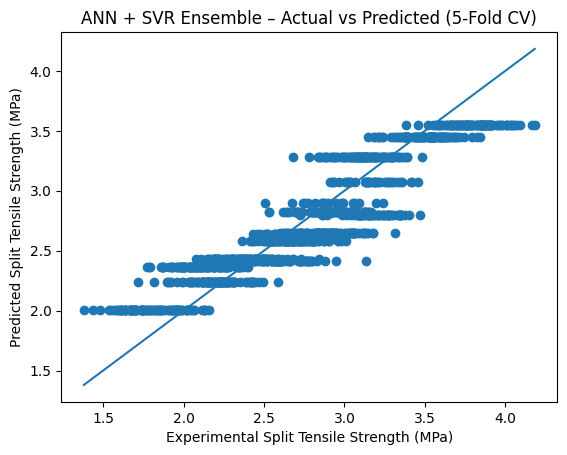

In [98]:
plt.figure()
plt.scatter(y, y_pred_ensemble)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Experimental Split Tensile Strength (MPa)")
plt.ylabel("Predicted Split Tensile Strength (MPa)")
plt.title("ANN + SVR Ensemble – Actual vs Predicted (5-Fold CV)")
plt.show()


In [99]:
results = pd.DataFrame({
    "Model": ["ANN", "SVR", "ANN + SVR Ensemble"],
    "R2": [
        r2_score(y, y_pred_ann),
        r2_score(y, y_pred_svr),
        r2_score(y, y_pred_ensemble)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y, y_pred_ann)),
        np.sqrt(mean_squared_error(y, y_pred_svr)),
        np.sqrt(mean_squared_error(y, y_pred_ensemble))
    ]
})

results


,Model,R2,RMSE
0,ANN,0.678236,0.330738
1,SVR,0.925137,0.159532
2,ANN + SVR Ensemble,0.838381,0.234402


In [100]:
from scipy.optimize import minimize

In [101]:
y                # true split tensile strength
y_pred_ann       # cross-validated ANN predictions
y_pred_svr       # cross-validated SVR predictions


array([1.7382018 , 1.7382018 , 1.7382018 , ..., 3.79320218, 3.79320218,
       3.79320218])

In [102]:
def ensemble_rmse(weights, y_true, pred_ann, pred_svr):
    w_ann, w_svr = weights
    y_ens = w_ann * pred_ann + w_svr * pred_svr
    return np.sqrt(mean_squared_error(y_true, y_ens))


In [103]:
# Constraint: w_ann + w_svr = 1
constraints = {
    "type": "eq",
    "fun": lambda w: w[0] + w[1] - 1
}

# Bounds: weights between 0 and 1
bounds = [(0, 1), (0, 1)]


In [104]:
initial_weights = [0.5, 0.5]

result = minimize(
    ensemble_rmse,
    initial_weights,
    args=(y, y_pred_ann, y_pred_svr),
    bounds=bounds,
    constraints=constraints
)

w_ann_opt, w_svr_opt = result.x

print("Optimized ANN weight :", round(w_ann_opt, 3))
print("Optimized SVR weight :", round(w_svr_opt, 3))


Optimized ANN weight : 0.017
Optimized SVR weight : 0.983


In [105]:
y_pred_ensemble_opt = (
    w_ann_opt * y_pred_ann +
    w_svr_opt * y_pred_svr
)


In [106]:
print("OPTIMIZED ENSEMBLE PERFORMANCE")
print("R2  :", r2_score(y, y_pred_ensemble_opt))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred_ensemble_opt)))


OPTIMIZED ENSEMBLE PERFORMANCE
R2  : 0.9252142073226798
RMSE: 0.15945003052403178


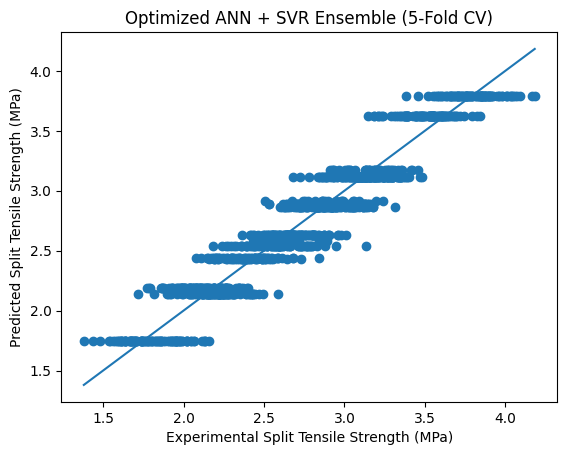

In [107]:
plt.figure()
plt.scatter(y, y_pred_ensemble_opt)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Experimental Split Tensile Strength (MPa)")
plt.ylabel("Predicted Split Tensile Strength (MPa)")
plt.title("Optimized ANN + SVR Ensemble (5-Fold CV)")
plt.show()


In [108]:
results = pd.DataFrame({
    "Model": ["ANN", "SVR", "ANN + SVR (Optimized)"],
    "R2": [
        r2_score(y, y_pred_ann),
        r2_score(y, y_pred_svr),
        r2_score(y, y_pred_ensemble_opt)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y, y_pred_ann)),
        np.sqrt(mean_squared_error(y, y_pred_svr)),
        np.sqrt(mean_squared_error(y, y_pred_ensemble_opt))
    ]
})

results


,Model,R2,RMSE
0,ANN,0.678236,0.330738
1,SVR,0.925137,0.159532
2,ANN + SVR (Optimized),0.925214,0.159450


In [109]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

rf_param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X, y)

print("Best RF parameters:", rf_grid.best_params_)

Best RF parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 400}


RF R2 : 0.6871052705449034
RF RMSE : 0.3261475946808604


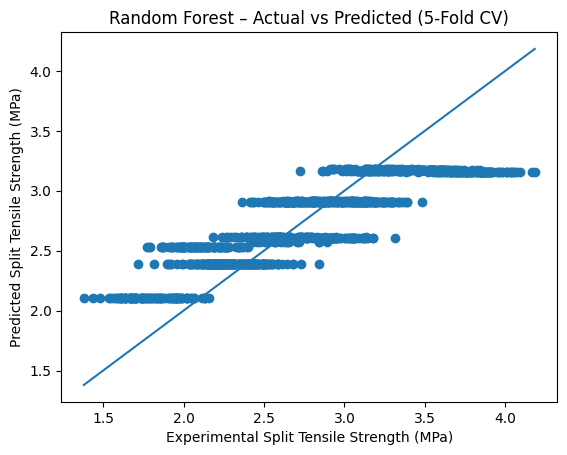

In [110]:
y_pred_rf = cross_val_predict(
    rf_grid.best_estimator_, X, y, cv=5
)

print("RF R2 :", r2_score(y, y_pred_rf))
print("RF RMSE :", np.sqrt(mean_squared_error(y, y_pred_rf)))

plt.figure()
plt.scatter(y, y_pred_rf)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Experimental Split Tensile Strength (MPa)")
plt.ylabel("Predicted Split Tensile Strength (MPa)")
plt.title("Random Forest – Actual vs Predicted (5-Fold CV)")
plt.show()


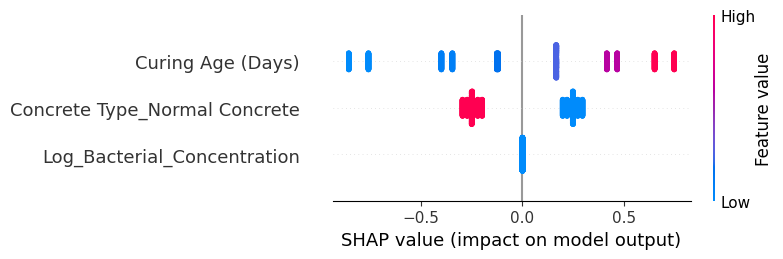

In [111]:
import shap

X_transformed = rf_grid.best_estimator_.named_steps["preprocessor"].transform(X)

ohe = rf_grid.best_estimator_.named_steps["preprocessor"] \
    .named_transformers_["cat"]

cat_features = ohe.get_feature_names_out(
    ["Concrete Type", "Cement", "Bacteria"]
)

feature_names = np.concatenate([
    ["Curing Age (Days)", "Log_Bacterial_Concentration"],
    cat_features
])

explainer = shap.TreeExplainer(
    rf_grid.best_estimator_.named_steps["model"]
)

shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names
)


In [112]:
y                # true Split Tensile Strength
y_pred_ann       # CV predictions from ANN (GridSearchCV)
y_pred_svr       # CV predictions from SVR (GridSearchCV)
y_pred_rf        # CV predictions from Random Forest (GridSearchCV)


array([2.10332346, 2.10332346, 2.10332346, ..., 3.15642039, 3.15642039,
       3.15642039])

In [113]:
def ensemble_rmse(weights, y_true, pred_ann, pred_svr, pred_rf):
    w_ann, w_svr, w_rf = weights
    y_ens = (
        w_ann * pred_ann +
        w_svr * pred_svr +
        w_rf * pred_rf
    )
    return np.sqrt(mean_squared_error(y_true, y_ens))


In [114]:
# Constraint: weights must sum to 1
constraints = {
    "type": "eq",
    "fun": lambda w: w[0] + w[1] + w[2] - 1
}

# Bounds: each weight between 0 and 1
bounds = [(0, 1), (0, 1), (0, 1)]


In [115]:
initial_weights = [1/3, 1/3, 1/3]

result = minimize(
    ensemble_rmse,
    initial_weights,
    args=(y, y_pred_ann, y_pred_svr, y_pred_rf),
    bounds=bounds,
    constraints=constraints
)

w_ann_opt, w_svr_opt, w_rf_opt = result.x

print("Optimized Weights")
print("ANN :", round(w_ann_opt, 3))
print("SVR :", round(w_svr_opt, 3))
print("RF  :", round(w_rf_opt, 3))


Optimized Weights
ANN : 0.0
SVR : 0.931
RF  : 0.069


In [116]:
y_pred_ensemble_opt = (
    w_ann_opt * y_pred_ann +
    w_svr_opt * y_pred_svr +
    w_rf_opt * y_pred_rf
)


In [117]:
print("OPTIMIZED ANN + SVR + RF ENSEMBLE")
print("R2  :", r2_score(y, y_pred_ensemble_opt))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred_ensemble_opt)))
print("MAE :", mean_absolute_error(y, y_pred_ensemble_opt))


OPTIMIZED ANN + SVR + RF ENSEMBLE
R2  : 0.9264753054943565
RMSE: 0.15809992737959427
MAE : 0.12526640467235373


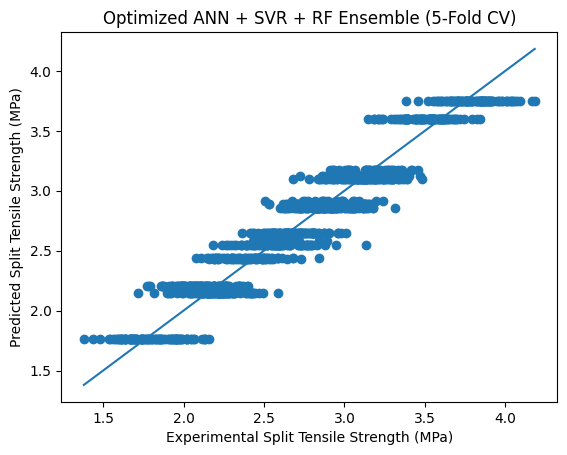

In [118]:
plt.figure()
plt.scatter(y, y_pred_ensemble_opt)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Experimental Split Tensile Strength (MPa)")
plt.ylabel("Predicted Split Tensile Strength (MPa)")
plt.title("Optimized ANN + SVR + RF Ensemble (5-Fold CV)")
plt.show()


In [119]:
results = pd.DataFrame({
    "Model": [
        "ANN",
        "SVR",
        "Random Forest",
        "ANN + SVR + RF (Optimized)"
    ],
    "R2": [
        r2_score(y, y_pred_ann),
        r2_score(y, y_pred_svr),
        r2_score(y, y_pred_rf),
        r2_score(y, y_pred_ensemble_opt)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y, y_pred_ann)),
        np.sqrt(mean_squared_error(y, y_pred_svr)),
        np.sqrt(mean_squared_error(y, y_pred_rf)),
        np.sqrt(mean_squared_error(y, y_pred_ensemble_opt))
    ]
})

results


,Model,R2,RMSE
0,ANN,0.678236,0.330738
1,SVR,0.925137,0.159532
2,Random Forest,0.687105,0.326148
3,ANN + SVR + RF (Optimized),0.926475,0.158100


In [120]:
import pandas as pd
import numpy as np

test_data = pd.DataFrame({
    "Concrete Type": [
        "Normal Concrete",
        "Bacterial Concrete",
        "Normal Concrete",
        "Bacterial Concrete",
        "Normal Concrete",
        "Bacterial Concrete",
        "Normal Concrete",
        "Bacterial Concrete",
        "Normal Concrete",
        "Bacterial Concrete"
    ],
    "Cement": [
        "OPC 53 (UltraTech)"
    ] * 10,
    "Bacteria": [
        "None",
        "Bacillus subtilis",
        "None",
        "Bacillus subtilis",
        "None",
        "Bacillus subtilis",
        "None",
        "Bacillus subtilis",
        "None",
        "Bacillus subtilis"
    ],
    "Curing Age (Days)": [
        7,   # Normal
        7,   # Bacterial
        14,
        14,
        21,
        21,
        28,
        28,
        56,
        56
    ],
    "Log_Bacterial_Concentration": [
        0.0,                 # Normal (no bacteria)
        np.log10(1_000_000), # Bacterial
        0.0,
        np.log10(1_000_000),
        0.0,
        np.log10(1_000_000),
        0.0,
        np.log10(1_000_000),
        0.0,
        np.log10(1_000_000)
    ]
})

test_data


,Concrete Type,Cement,Bacteria,Curing Age (Days),Log_Bacterial_Concentration
0,Normal Concrete,OPC 53 (UltraTech),None,7,0.0
1,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,7,6.0
2,Normal Concrete,OPC 53 (UltraTech),None,14,0.0
3,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,14,6.0
4,Normal Concrete,OPC 53 (UltraTech),None,21,0.0
5,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,21,6.0
6,Normal Concrete,OPC 53 (UltraTech),None,28,0.0
7,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,28,6.0
8,Normal Concrete,OPC 53 (UltraTech),None,56,0.0
9,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,56,6.0


In [121]:
df["Bacteria"] = df["Bacteria"].fillna("No Bacteria")


In [122]:
test_data["Bacteria"] = "Bacillus subtilis"


In [123]:
ann_pipeline
# Example: ensemble already trained
ann_pipeline.fit(X, y)
svr_pipeline.fit(X, y)
rf_pipeline.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Curing Age (Days)',
                                                   'Log_Bacterial_Concentration']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Concrete Type', 'Cement',
                                                   'Bacteria'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [125]:
pred_ann = ann_pipeline.predict(test_data)
pred_svr = svr_pipeline.predict(test_data)
pred_rf  = rf_pipeline.predict(test_data)

test_data["Predicted_STS_Ensemble (MPa)"] = (
    w_ann_opt * pred_ann +
    w_svr_opt * pred_svr +
    w_rf_opt  * pred_rf
)

In [126]:
test_data

,Concrete Type,Cement,Bacteria,Curing Age (Days),Log_Bacterial_Concentration,Predicted_STS_Ensemble (MPa)
0,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,7,0.0,2.625012
1,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,7,6.0,2.127612
2,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,14,0.0,2.652304
3,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,14,6.0,2.550118
4,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,21,0.0,2.665338
5,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,21,6.0,2.915679
6,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,28,0.0,2.685820
7,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,28,6.0,3.182402
8,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,56,0.0,2.701392
9,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,56,6.0,3.494156


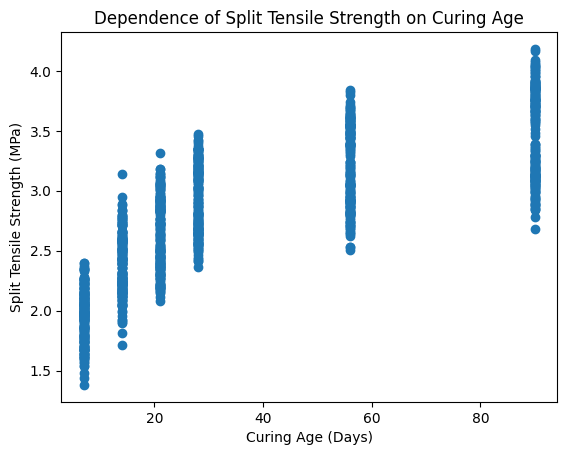

In [127]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["Curing Age (Days)"], y)
plt.xlabel("Curing Age (Days)")
plt.ylabel("Split Tensile Strength (MPa)")
plt.title("Dependence of Split Tensile Strength on Curing Age")
plt.show()


# Should show increasing trend

# Confirms age is dominant factor

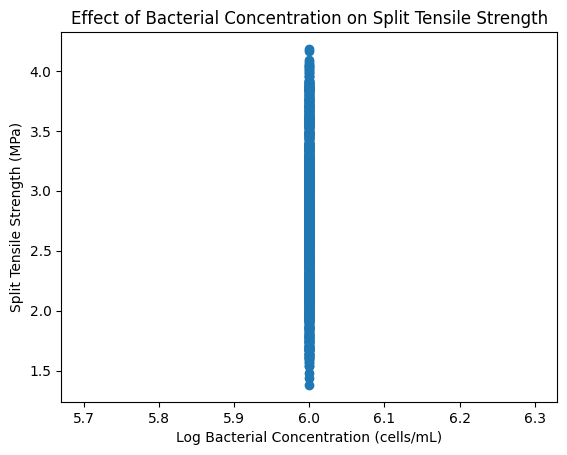

In [128]:
plt.figure()
plt.scatter(df["Log_Bacterial_Concentration"], y)
plt.xlabel("Log Bacterial Concentration (cells/mL)")
plt.ylabel("Split Tensile Strength (MPa)")
plt.title("Effect of Bacterial Concentration on Split Tensile Strength")
plt.show()

# Shows nonlinear increase

# Confirms bacterial activity effect


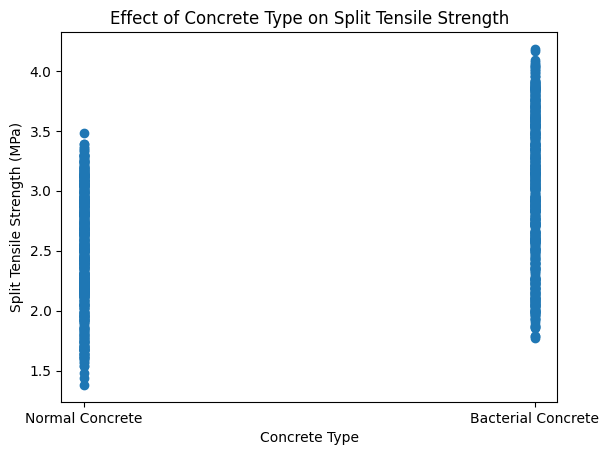

In [129]:
plt.figure()
plt.scatter(df["Concrete Type"], y)
plt.xlabel("Concrete Type")
plt.ylabel("Split Tensile Strength (MPa)")
plt.title("Effect of Concrete Type on Split Tensile Strength")
plt.show()

# Bacterial concrete cluster should be higher

# Confirms categorical influence


In [130]:
# Extract trained RF model
rf_model = rf_grid.best_estimator_.named_steps["model"]

# Get feature names from encoder
ohe = rf_grid.best_estimator_.named_steps["preprocessor"].named_transformers_["cat"]

cat_features = ohe.get_feature_names_out(
    ["Concrete Type", "Cement", "Bacteria"]
)

feature_names = list(["Curing Age (Days)", "Log_Bacterial_Concentration"]) + list(cat_features)

# Importance values
importances = rf_model.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                         Feature  Importance
0              Curing Age (Days)    0.798548
2  Concrete Type_Normal Concrete    0.201452
1    Log_Bacterial_Concentration    0.000000


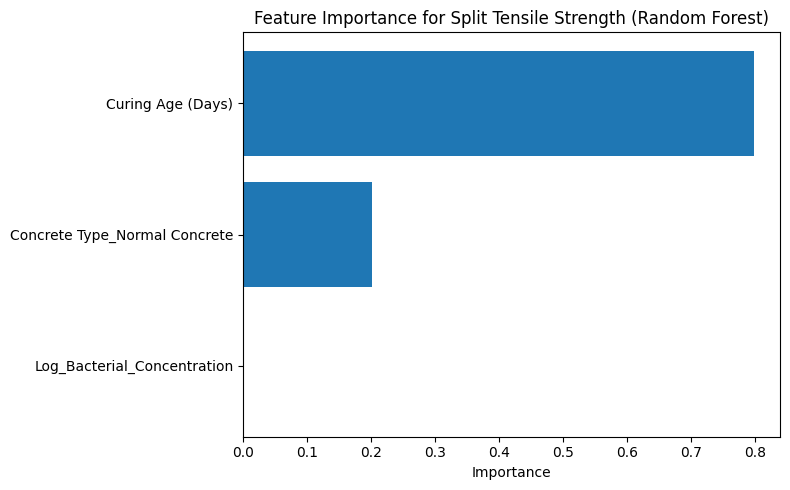

In [131]:
plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance for Split Tensile Strength (Random Forest)")
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.tight_layout()
plt.show()

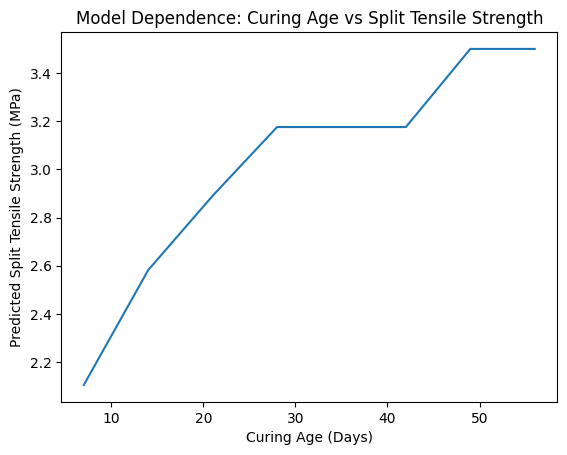

In [133]:
ages = np.arange(7, 57, 7)

temp_df = pd.DataFrame({
    "Concrete Type": ["Bacterial Concrete"] * len(ages),
    "Cement": ["OPC 53 (UltraTech)"] * len(ages),
    "Bacteria": ["Bacillus subtilis"] * len(ages),
    "Curing Age (Days)": ages,
    "Log_Bacterial_Concentration": [np.log10(1_000_000)] * len(ages)
})

predicted_strength = rf_grid.best_estimator_.predict(temp_df)

plt.figure()
plt.plot(ages, predicted_strength)
plt.xlabel("Curing Age (Days)")
plt.ylabel("Predicted Split Tensile Strength (MPa)")
plt.title("Model Dependence: Curing Age vs Split Tensile Strength")
plt.show()

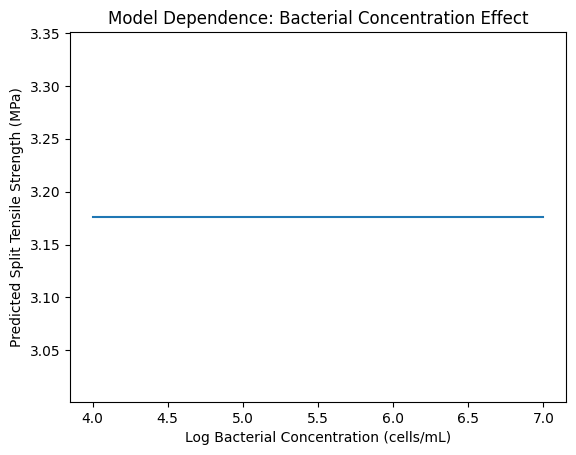

In [134]:
concs = np.log10([1e4, 1e5, 1e6, 1e7])

temp_df = pd.DataFrame({
    "Concrete Type": ["Bacterial Concrete"] * len(concs),
    "Cement": ["OPC 53 (UltraTech)"] * len(concs),
    "Bacteria": ["Bacillus subtilis"] * len(concs),
    "Curing Age (Days)": [28] * len(concs),
    "Log_Bacterial_Concentration": concs
})

predicted_strength = rf_grid.best_estimator_.predict(temp_df)

plt.figure()
plt.plot(concs, predicted_strength)
plt.xlabel("Log Bacterial Concentration (cells/mL)")
plt.ylabel("Predicted Split Tensile Strength (MPa)")
plt.title("Model Dependence: Bacterial Concentration Effect")
plt.show()

In [137]:

np.random.seed(42)

rows = []

curing_days = [7, 14, 21, 28, 56]
concrete_types = ["Normal Concrete", "Bacterial Concrete"]
bacterial_levels = [0, 1e4, 1e5, 1e6]

for day in curing_days:
    for conc in bacterial_levels:
        for _ in range(3):  # replicate to reach ~50 rows

            if conc == 0:
                concrete_type = "Normal Concrete"
                bacteria = "Bacillus subtilis"
                log_conc = 0.0

            else:
                concrete_type = "Bacterial Concrete"
                bacteria = "Bacillus subtilis"
                log_conc = np.log10(conc)




            rows.append([
                concrete_type,
                "OPC 53 (UltraTech)",
                bacteria,
                day,
                log_conc,

            ])

train_df = pd.DataFrame(
    rows,
    columns=[
        "Concrete Type",
        "Cement",
        "Bacteria",
        "Curing Age (Days)",
        "Log_Bacterial_Concentration",

    ]
)

train_df = train_df.sample(n=50, random_state=42).reset_index(drop=True)

train_df

,Concrete Type,Cement,Bacteria,Curing Age (Days),Log_Bacterial_Concentration
0,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,7,0.0
1,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,7,4.0
2,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,28,0.0
3,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,28,6.0
4,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,14,0.0
5,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,56,5.0
6,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,21,6.0
7,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,56,0.0
8,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,14,0.0
9,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,56,6.0


In [139]:
pred_ann = ann_pipeline.predict(train_df)
pred_svr = svr_pipeline.predict(train_df)
pred_rf  = rf_pipeline.predict(train_df)

train_df["Predicted_STS_Ensemble (MPa)"] = (
    w_ann_opt * pred_ann +
    w_svr_opt * pred_svr +
    w_rf_opt  * pred_rf
)

In [140]:
train_df

,Concrete Type,Cement,Bacteria,Curing Age (Days),Log_Bacterial_Concentration,Predicted_STS_Ensemble (MPa)
0,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,7,0.0,2.625012
1,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,7,4.0,2.615100
2,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,28,0.0,2.685820
3,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,28,6.0,3.182402
4,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,14,0.0,2.652304
5,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,56,5.0,3.113589
6,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,21,6.0,2.915679
7,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,56,0.0,2.701392
8,Normal Concrete,OPC 53 (UltraTech),Bacillus subtilis,14,0.0,2.652304
9,Bacterial Concrete,OPC 53 (UltraTech),Bacillus subtilis,56,6.0,3.494156


In [141]:
# 1. Get predictions of individual models on the full training data (X)
pred_ann_train = ann_grid.best_estimator_.predict(X)
pred_svr_train = svr_grid.best_estimator_.predict(X)
pred_rf_train  = rf_grid.best_estimator_.predict(X)

# 2. Combine these predictions using the optimized ensemble weights
#    (w_ann_opt, w_svr_opt, w_rf_opt were determined earlier)
y_pred_ensemble_train = (
    w_ann_opt * pred_ann_train +
    w_svr_opt * pred_svr_train +
    w_rf_opt  * pred_rf_train
)

# 3. Calculate R2 and RMSE for the ensemble on the training data
r2_train = r2_score(y, y_pred_ensemble_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_ensemble_train))

print("Ensemble Performance on Training Data:")
print(f"R2 (Training): {r2_train:.4f}")
print(f"RMSE (Training): {rmse_train:.4f}")

print("\nEnsemble Performance (Cross-Validated) for comparison:")
print(f"R2 (Cross-Validated): {r2_score(y, y_pred_ensemble_opt):.4f}")
print(f"RMSE (Cross-Validated): {np.sqrt(mean_squared_error(y, y_pred_ensemble_opt)):.4f}")

Ensemble Performance on Training Data:
R2 (Training): 0.9328
RMSE (Training): 0.1512

Ensemble Performance (Cross-Validated) for comparison:
R2 (Cross-Validated): 0.9265
RMSE (Cross-Validated): 0.1581
